# Fourier decomposition of the July 1 candidate population

This notebook explores the **stored, BIC-selected phase-folded Fourier decompositions** for the full July 1 Review population (expected: 22,942 candidates). It is an audit of the existing `stats_harmonics_*` fields; it does not rerun period finding or refit light curves.

The decomposition is fit at the adopted period. Each accepted harmonic contributes a sine coefficient $a_k$ and a cosine coefficient $b_k$, with the order selected from 1–7 by BIC. Derived amplitudes, amplitude ratios, and phase combinations describe that same selected model. A finite Fourier fit is a descriptive representation of a folded light curve—not proof that a candidate is periodic or that its adopted period is physically correct.

## Questions answered

1. How complete are the stored Fourier fits, and what harmonic order did BIC select?
2. How do adopted period, model amplitude, and reduced $\chi^2$ relate?
3. How much power is carried by each harmonic, and how stable are the stored coefficient/amplitude fields?
4. Which folded-shape regions appear in $(R_{21},\phi_{21})$ and $(R_{31},\phi_{31})$?
5. How do the available human Review classes compare, without treating sparse labels as a complete population taxonomy?
6. What do representative **model curves** look like for high-amplitude, high-complexity, high-order, and poor-fit cases?
7. How do Fourier coverage, periods, amplitudes, fit quality, shape parameters, and model profiles differ for candidates independently labeled as semiregular variables in the external ASAS-SN variable catalog?

## Parameters and imports

The default input is the July 1 Review database. Set `MALCA_FOURIER_INPUT` to a `.db` or `.parquet` source for a different population, and `MALCA_FOURIER_OUTPUT_DIR` to redirect saved figures. No input data are modified.

In [1]:
from __future__ import annotations

import os
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from malca.io.notebook_paths import find_repo_root
from malca.vsx.filter import tokenize_classes as tokenize_catalog_classes

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 220,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
})
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4g}')

REPO_ROOT = find_repo_root()
RUN_NAME = 'dat3-full-extended_2026-07-01-v4'
RUN_ROOT = REPO_ROOT / 'output' / 'runs' / RUN_NAME
DEFAULT_INPUT = RUN_ROOT / 'review' / 'review.db'
INPUT_TEXT = os.environ.get('MALCA_FOURIER_INPUT', '').strip()
INPUT_SOURCE = Path(INPUT_TEXT).expanduser() if INPUT_TEXT else DEFAULT_INPUT
if not INPUT_SOURCE.is_absolute():
    INPUT_SOURCE = REPO_ROOT / INPUT_SOURCE
OUTPUT_TEXT = os.environ.get('MALCA_FOURIER_OUTPUT_DIR', '').strip()
OUTPUT_DIR = Path(OUTPUT_TEXT).expanduser() if OUTPUT_TEXT else REPO_ROOT / 'output' / 'notebooks' / 'july1_fourier_candidate_population'
if not OUTPUT_DIR.is_absolute():
    OUTPUT_DIR = REPO_ROOT / OUTPUT_DIR
FIG_DIR = OUTPUT_DIR / 'figures'
EXPECTED_CANDIDATES = 22_942
MAX_PLOT_CLASSES = 12

assert INPUT_SOURCE.suffix.lower() in {'.db', '.sqlite', '.sqlite3', '.parquet'}, INPUT_SOURCE
if not INPUT_SOURCE.is_file():
    raise FileNotFoundError(
        f'Candidate source not found: {INPUT_SOURCE}\n'
        'Mount the July 1 run or set MALCA_FOURIER_INPUT to its Review DB or enriched parquet.'
    )
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f'input      : {INPUT_SOURCE}')
print(f'output dir : {OUTPUT_DIR}')


input      : /Users/calder/code/malca/output/runs/dat3-full-extended_2026-07-01-v4/review/review.db
output dir : /Users/calder/code/malca/output/notebooks/july1_fourier_candidate_population


/opt/homebrew/Caskroom/miniconda/base/envs/malca/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load only the fields used in this audit

For a Review DB, the notebook reads selected columns from `candidates` and joins the current `reviews.event_class`. For a parquet it reads the table directly. The code is schema-tolerant: absent optional context fields remain missing rather than being fabricated.

In [2]:
HARMONIC_ORDERS = tuple(range(1, 8))
HARMONIC_COLUMNS = [
    'stats_harmonics_order', 'stats_harmonics_period', 'stats_harmonics_a0',
    'stats_harmonics_model_amplitude', 'stats_harmonics_reduced_chi2',
    'stats_harmonics_mse',
    *[f'stats_harmonics_mag_{k}' for k in HARMONIC_ORDERS],
    *[f'stats_harmonics_a{k}' for k in HARMONIC_ORDERS],
    *[f'stats_harmonics_b{k}' for k in HARMONIC_ORDERS],
    *[f'stats_harmonics_r{k}1' for k in range(2, 8)],
    *[f'stats_harmonics_phase_{k}' for k in range(2, 8)],
]
CONTEXT_COLUMNS = [
    'candidate_id', 'lc_path', 'source_id', 'asas_sn_id', 'final_class',
    'asassn_var_name', 'asassn_var_type', 'asassn_var_period',
    'periodicity_period', 'periodicity_period_source',
    'stats_variability_periodic_feature_period_days',
    'stats_variability_periodic_feature_period_source',
    'dipper_score', 'P_eb', 'P_disk',
]

def _quote(name: str) -> str:
    return '"' + str(name).replace('"', '""') + '"'

def load_population(source: Path) -> pd.DataFrame:
    if source.suffix.lower() == '.parquet':
        return pd.read_parquet(source)

    with sqlite3.connect(source) as conn:
        candidate_columns = pd.read_sql_query('PRAGMA table_info(candidates)', conn)['name'].tolist()
        wanted = [name for name in [*CONTEXT_COLUMNS, *HARMONIC_COLUMNS] if name in candidate_columns]
        if 'candidate_id' not in wanted:
            raise ValueError('Review DB candidates table has no candidate_id column.')
        query = f"SELECT {', '.join(_quote(name) for name in wanted)} FROM candidates"
        frame = pd.read_sql_query(query, conn)
        tables = set(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'])
        if 'reviews' in tables:
            review_columns = pd.read_sql_query('PRAGMA table_info(reviews)', conn)['name'].tolist()
            if {'candidate_id', 'event_class'}.issubset(review_columns):
                classes = pd.read_sql_query('SELECT candidate_id, event_class FROM reviews', conn)
                frame = frame.merge(classes, on='candidate_id', how='left', validate='one_to_one')
    return frame

population = load_population(INPUT_SOURCE)
if population.empty:
    raise ValueError(f'No candidates loaded from {INPUT_SOURCE}')
if 'candidate_id' not in population:
    raise ValueError('Input must contain candidate_id.')
population['candidate_id'] = population['candidate_id'].astype('string')
if population['candidate_id'].isna().any() or population['candidate_id'].duplicated().any():
    raise ValueError('candidate_id must be present and unique for this population audit.')

for column in HARMONIC_COLUMNS:
    if column in population:
        population[column] = pd.to_numeric(population[column], errors='coerce')
for column in ('dipper_score', 'P_eb', 'P_disk', 'periodicity_period', 'stats_variability_periodic_feature_period_days', 'asassn_var_period'):
    if column in population:
        population[column] = pd.to_numeric(population[column], errors='coerce')

if 'event_class' not in population:
    population['event_class'] = pd.NA
population['event_class_display'] = population['event_class'].fillna('not reviewed').astype('string')
print(f'Loaded {len(population):,} candidates.')
if len(population) != EXPECTED_CANDIDATES:
    print(f'Note: expected {EXPECTED_CANDIDATES:,} for the July 1 cohort; this source contains {len(population):,}.')
display(population[[column for column in ['candidate_id', 'event_class_display', 'stats_harmonics_order', 'stats_harmonics_period', 'stats_harmonics_model_amplitude', 'stats_harmonics_reduced_chi2'] if column in population]].head())


Loaded 22,942 candidates.


,candidate_id,event_class_display,stats_harmonics_order,stats_harmonics_period,stats_harmonics_model_amplitude,stats_harmonics_reduced_chi2
0,stv_128850352739,not reviewed,7,5.701,0.04296,60.46
1,stv_128850377787,not reviewed,7,1.551,0.1438,24.33
2,stv_128850401454,not reviewed,1,1.841,0.008579,1.933
3,stv_128850429575,dipper,1,11.96,0.01307,13.61
4,stv_128850443837,not reviewed,7,7.98,0.05798,266.4


## Derive model-consistent quantities

The code below reconstructs $A_k=\sqrt{a_k^2+b_k^2}$ and $\phi_{k1}=\phi_k-k\phi_1$ from the stored coefficients. These provide an internal consistency check against the persisted `stats_harmonics_mag_*` and phase fields. Only coefficients at or below the BIC-selected order are considered populated.

In [3]:
order = population.get('stats_harmonics_order', pd.Series(np.nan, index=population.index))
period = population.get('stats_harmonics_period', pd.Series(np.nan, index=population.index))
fit_mask = order.between(1, 7) & period.gt(0)
fits = population.loc[fit_mask].copy()
fits['harmonic_order'] = fits['stats_harmonics_order'].round().astype('Int64')
fits['period_days'] = fits['stats_harmonics_period']
fits['model_amplitude'] = fits.get('stats_harmonics_model_amplitude', np.nan)
fits['reduced_chi2'] = fits.get('stats_harmonics_reduced_chi2', np.nan)
fits['a0'] = fits.get('stats_harmonics_a0', np.nan)

for k in HARMONIC_ORDERS:
    a = fits.get(f'stats_harmonics_a{k}', pd.Series(np.nan, index=fits.index))
    b = fits.get(f'stats_harmonics_b{k}', pd.Series(np.nan, index=fits.index))
    fits[f'A{k}_from_coeff'] = np.hypot(a, b)
    stored = fits.get(f'stats_harmonics_mag_{k}', pd.Series(np.nan, index=fits.index))
    fits[f'A{k}_stored'] = stored
    fits[f'A{k}'] = fits[f'A{k}_from_coeff'].combine_first(stored)
    fits.loc[fits['harmonic_order'] < k, [f'A{k}_from_coeff', f'A{k}_stored', f'A{k}']] = np.nan

for k in range(2, 8):
    denominator = fits['A1_from_coeff']
    fits[f'R{k}1_from_coeff'] = fits[f'A{k}_from_coeff'] / denominator.where(denominator.gt(0))
    stored_ratio = fits.get(f'stats_harmonics_r{k}1', pd.Series(np.nan, index=fits.index))
    a1 = fits.get('stats_harmonics_a1', pd.Series(np.nan, index=fits.index))
    b1 = fits.get('stats_harmonics_b1', pd.Series(np.nan, index=fits.index))
    ak = fits.get(f'stats_harmonics_a{k}', pd.Series(np.nan, index=fits.index))
    bk = fits.get(f'stats_harmonics_b{k}', pd.Series(np.nan, index=fits.index))
    phi1 = np.mod(np.arctan2(-a1, b1), 2 * np.pi)
    phik = np.mod(np.arctan2(-ak, bk), 2 * np.pi)
    fits[f'phi{k}1_from_coeff'] = np.mod(phik - k * phi1, 2 * np.pi)
    stored_phase = fits.get(f'stats_harmonics_phase_{k}', pd.Series(np.nan, index=fits.index))
    fits[f'R{k}1'] = fits[f'R{k}1_from_coeff'].combine_first(stored_ratio)
    fits[f'phi{k}1'] = fits[f'phi{k}1_from_coeff'].combine_first(stored_phase)
    fits.loc[fits['harmonic_order'] < k, [f'R{k}1_from_coeff', f'phi{k}1_from_coeff', f'R{k}1', f'phi{k}1']] = np.nan

coverage = pd.DataFrame({
    'quantity': ['candidate rows', 'finite selected order', 'positive Fourier period', 'valid Fourier fit', 'finite first-harmonic coefficient pair'],
    'count': [
        len(population),
        int(order.between(1, 7).sum()),
        int(period.gt(0).sum()),
        len(fits),
        int((np.isfinite(fits.get('stats_harmonics_a1', np.nan)) & np.isfinite(fits.get('stats_harmonics_b1', np.nan))).sum()),
    ],
})
coverage['fraction_of_population'] = coverage['count'] / len(population)
order_counts = fits['harmonic_order'].value_counts().reindex(HARMONIC_ORDERS, fill_value=0).rename_axis('harmonic_order').reset_index(name='n_candidates')
order_counts['fraction_of_fits'] = order_counts['n_candidates'] / len(fits) if len(fits) else np.nan

coefficient_long = pd.concat([
    pd.DataFrame({
        'candidate_id': fits['candidate_id'],
        'harmonic': k,
        'a': fits.get(f'stats_harmonics_a{k}', np.nan),
        'b': fits.get(f'stats_harmonics_b{k}', np.nan),
        'amplitude': fits[f'A{k}'],
        'amplitude_ratio_to_A1': 1.0 if k == 1 else fits[f'R{k}1'],
        'phase_combination': np.nan if k == 1 else fits[f'phi{k}1'],
        'harmonic_order': fits['harmonic_order'],
        'event_class_display': fits['event_class_display'],
    }).loc[fits['harmonic_order'] >= k]
    for k in HARMONIC_ORDERS
], ignore_index=True)

summary = coverage.copy()
summary.to_csv(OUTPUT_DIR / 'fourier_coverage_summary.csv', index=False)
order_counts.to_csv(OUTPUT_DIR / 'fourier_order_counts.csv', index=False)
coefficient_long.to_parquet(OUTPUT_DIR / 'fourier_coefficients_long.parquet', index=False)
display(coverage)
display(order_counts)


,quantity,count,fraction_of_population
0,candidate rows,22942,1
1,finite selected order,22942,1
2,positive Fourier period,22942,1
3,valid Fourier fit,22942,1
4,finite first-harmonic coefficient pair,22942,1


,harmonic_order,n_candidates,fraction_of_fits
0,1,2940,0.1281
1,2,738,0.03217
2,3,606,0.02641
3,4,1790,0.07802
4,5,1097,0.04782
5,6,5203,0.2268
6,7,10568,0.4606


## Plot helpers

All figures are saved under `output/notebooks/july1_fourier_candidate_population/figures/` by default. The output directory is versionable scientific evidence: it records the exact source path and generated tables, while leaving the run products untouched.

In [4]:
figure_manifest: list[dict[str, str]] = []

def save_show(fig: plt.Figure, stem: str) -> None:
    path = FIG_DIR / f'{stem}.png'
    fig.tight_layout()
    fig.savefig(path, bbox_inches='tight')
    figure_manifest.append({'figure': stem, 'path': str(path.relative_to(OUTPUT_DIR))})
    display(fig)
    plt.close(fig)

def finite_xy(frame: pd.DataFrame, x: str, y: str) -> pd.DataFrame:
    return frame.loc[np.isfinite(frame[x]) & np.isfinite(frame[y]), [x, y]].copy()

def clipped_limits(values: pd.Series | np.ndarray, lower: float = 0.01, upper: float = 0.99) -> tuple[float, float]:
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return (0.0, 1.0)
    lo, hi = np.quantile(finite, [lower, upper])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
        pad = max(abs(float(lo)) * 0.05, 1e-6)
        return float(lo - pad), float(hi + pad)
    return float(lo), float(hi)

def log10_positive(series: pd.Series | np.ndarray) -> np.ndarray:
    values = np.asarray(series, dtype=float)
    out = np.full(values.shape, np.nan)
    good = np.isfinite(values) & (values > 0)
    out[good] = np.log10(values[good])
    return out

def plot_log_hist(ax: plt.Axes, values: pd.Series | np.ndarray, *, color: str, xlabel: str, title: str) -> None:
    logged = log10_positive(values)
    logged = logged[np.isfinite(logged)]
    if logged.size:
        ax.hist(logged, bins=min(55, max(10, int(np.sqrt(logged.size)))), color=color)
    else:
        ax.text(0.5, 0.5, 'No positive finite values', ha='center', va='center', transform=ax.transAxes)
    ax.set(xlabel=xlabel, ylabel='Candidates', title=title)


## Fourier coverage, selected complexity, and scalar fit diagnostics

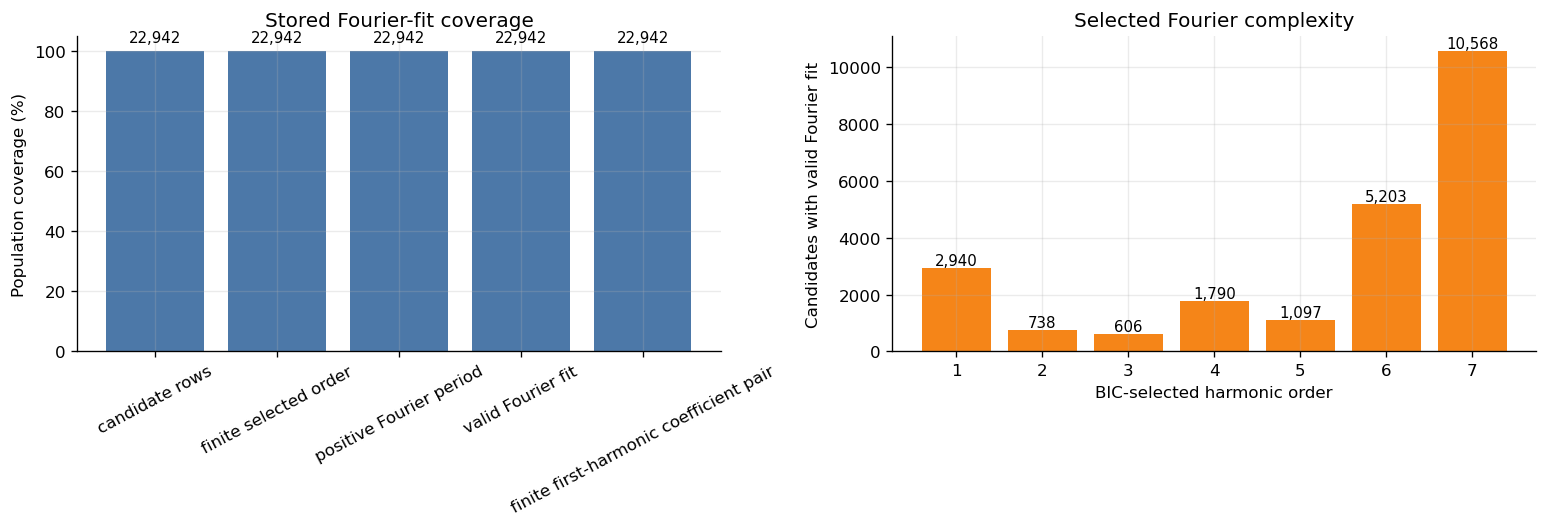

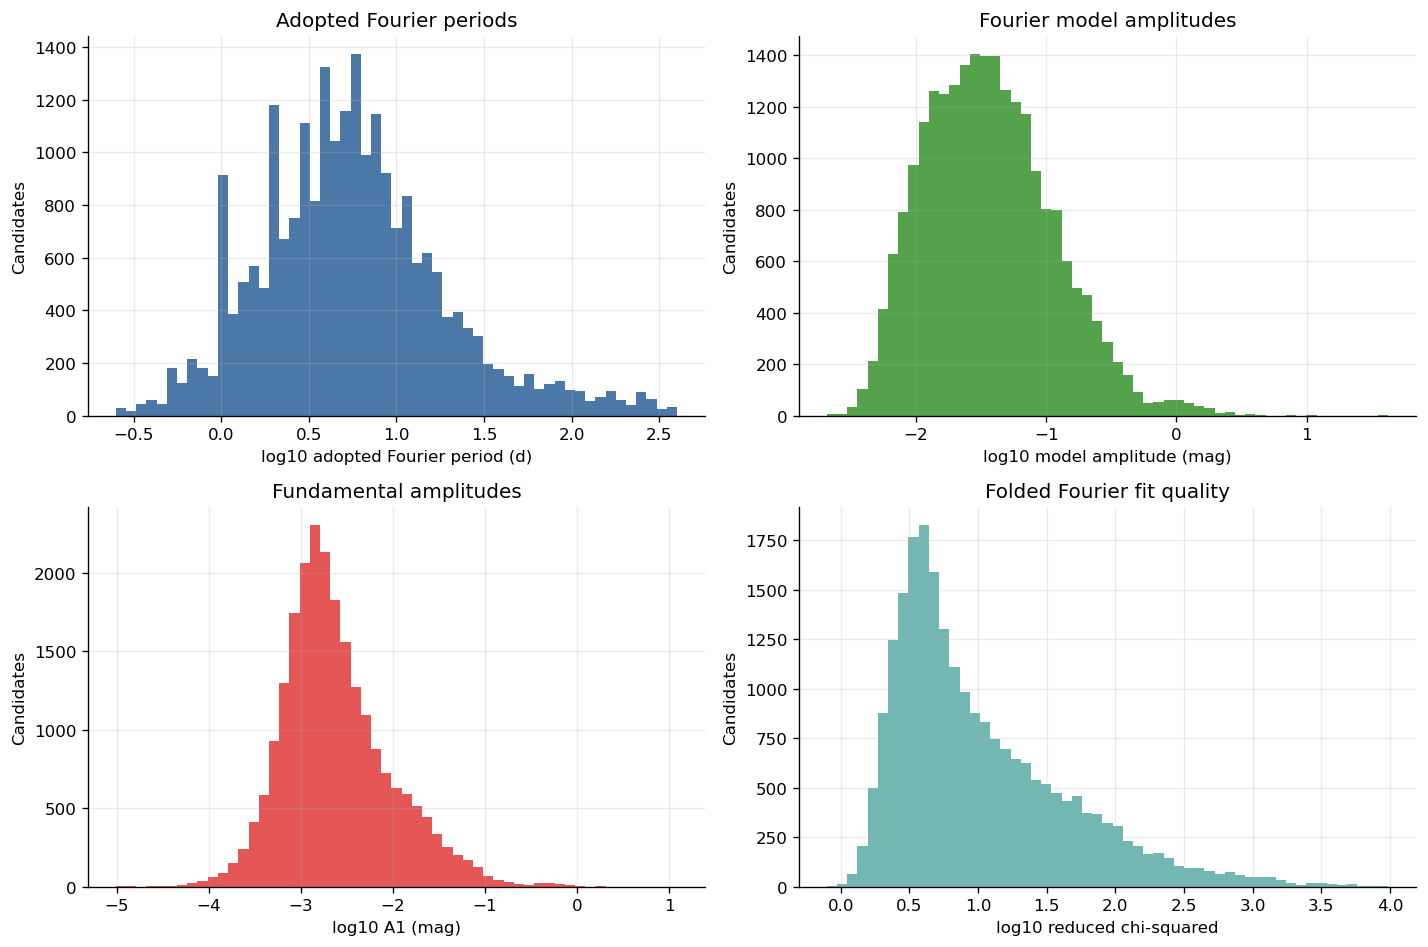

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(coverage['quantity'], coverage['fraction_of_population'] * 100, color='#4c78a8')
axes[0].set_ylabel('Population coverage (%)')
axes[0].set_ylim(0, 105)
axes[0].tick_params(axis='x', rotation=28)
axes[0].set_title('Stored Fourier-fit coverage')
for idx, row in coverage.iterrows():
    axes[0].text(idx, row['fraction_of_population'] * 100 + 2, f"{int(row['count']):,}", ha='center', va='bottom', fontsize=9)
axes[1].bar(order_counts['harmonic_order'].astype(str), order_counts['n_candidates'], color='#f58518')
axes[1].set_xlabel('BIC-selected harmonic order')
axes[1].set_ylabel('Candidates with valid Fourier fit')
axes[1].set_title('Selected Fourier complexity')
for _, row in order_counts.iterrows():
    axes[1].text(int(row['harmonic_order']) - 1, row['n_candidates'], f"{int(row['n_candidates']):,}", ha='center', va='bottom', fontsize=9)
save_show(fig, '01_coverage_and_selected_order')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_log_hist(axes[0, 0], fits['period_days'], color='#4c78a8', xlabel='log10 adopted Fourier period (d)', title='Adopted Fourier periods')
plot_log_hist(axes[0, 1], fits['model_amplitude'], color='#54a24b', xlabel='log10 model amplitude (mag)', title='Fourier model amplitudes')
plot_log_hist(axes[1, 0], fits['A1'], color='#e45756', xlabel='log10 A1 (mag)', title='Fundamental amplitudes')
plot_log_hist(axes[1, 1], fits['reduced_chi2'], color='#72b7b2', xlabel='log10 reduced chi-squared', title='Folded Fourier fit quality')
save_show(fig, '02_scalar_fourier_distributions')


## Period, amplitude, and fit-quality relationships

These density plots deliberately retain all valid stored Fourier fits. A high reduced $\chi^2$ flags that the BIC-selected periodic harmonic model does not describe the folded data well; it is not itself a classification.

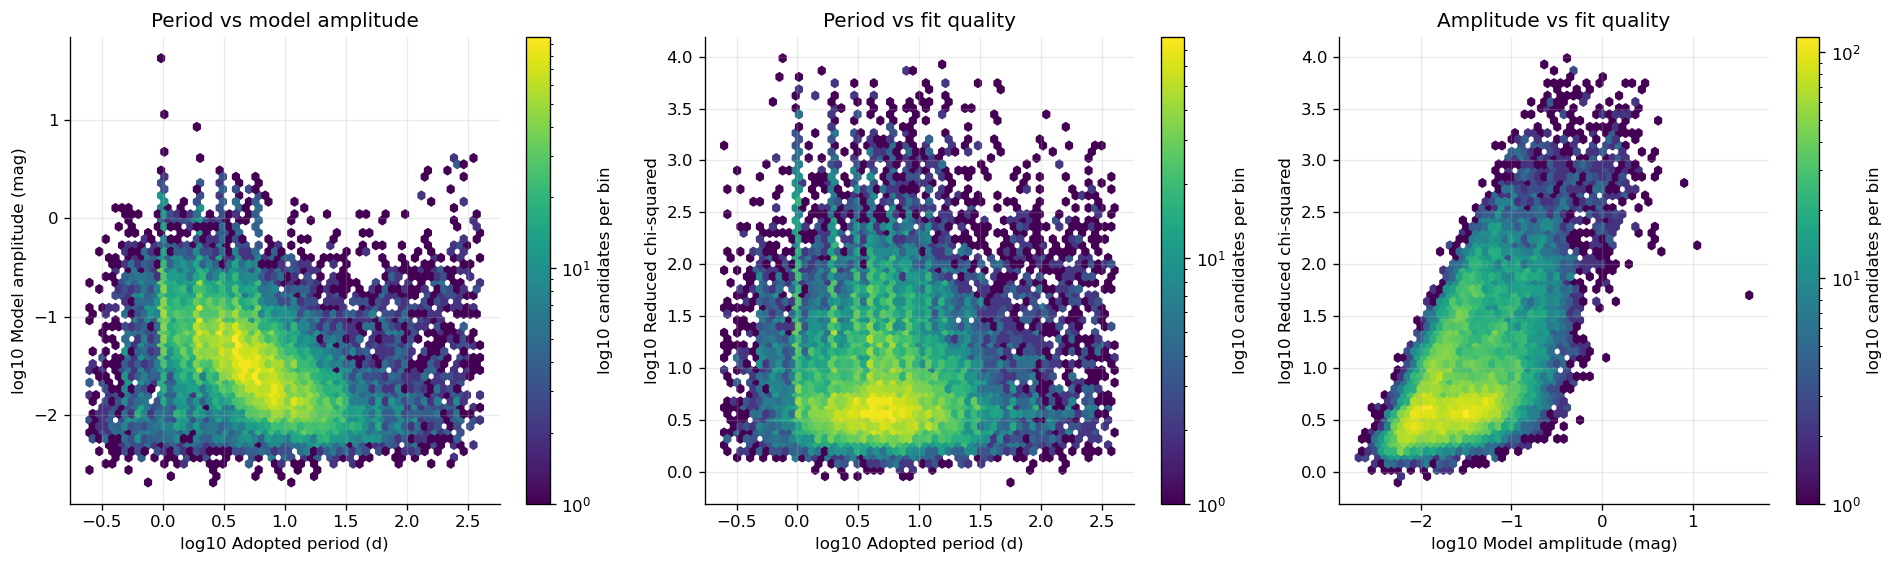

/private/tmp/ipykernel_78002/3316868563.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(chi2_by_order, labels=HARMONIC_ORDERS, showfliers=False)


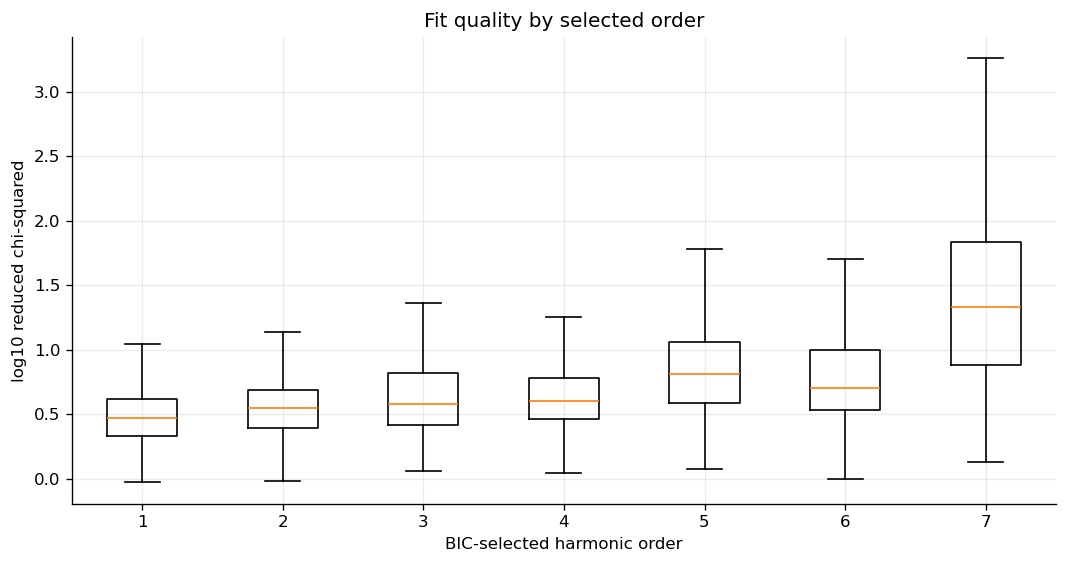

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
relationship_specs = [
    ('period_days', 'model_amplitude', 'Adopted period (d)', 'Model amplitude (mag)', 'Period vs model amplitude'),
    ('period_days', 'reduced_chi2', 'Adopted period (d)', 'Reduced chi-squared', 'Period vs fit quality'),
    ('model_amplitude', 'reduced_chi2', 'Model amplitude (mag)', 'Reduced chi-squared', 'Amplitude vs fit quality'),
]
for ax, (x, y, xlabel, ylabel, title) in zip(axes, relationship_specs):
    data = finite_xy(fits, x, y)
    data = data.loc[(data[x] > 0) & (data[y] > 0)]
    hb = ax.hexbin(np.log10(data[x]), np.log10(data[y]), gridsize=60, mincnt=1, cmap='viridis', bins='log')
    fig.colorbar(hb, ax=ax, label='log10 candidates per bin')
    ax.set(xlabel=f'log10 {xlabel}', ylabel=f'log10 {ylabel}', title=title)
save_show(fig, '03_period_amplitude_fit_quality')

chi2_by_order = [
    log10_positive(fits.loc[fits['harmonic_order'].eq(k), 'reduced_chi2'])
    for k in HARMONIC_ORDERS
]
chi2_by_order = [values[np.isfinite(values)] for values in chi2_by_order]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.boxplot(chi2_by_order, labels=HARMONIC_ORDERS, showfliers=False)
ax.set(xlabel='BIC-selected harmonic order', ylabel='log10 reduced chi-squared', title='Fit quality by selected order')
save_show(fig, '04_fit_quality_by_selected_order')


## Harmonic content and persistence checks

The first panel shows the population distribution of each fitted harmonic amplitude. The second uses $A_k/A_1$ and therefore excludes cases with non-positive or non-finite $A_1$. The third checks that amplitudes recomputed from $(a_k,b_k)$ agree with the saved amplitude columns.

/private/tmp/ipykernel_78002/3283079337.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(amp_by_k, labels=HARMONIC_ORDERS, showfliers=False)
/private/tmp/ipykernel_78002/3283079337.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(ratio_by_k, labels=range(2, 8), showfliers=False)


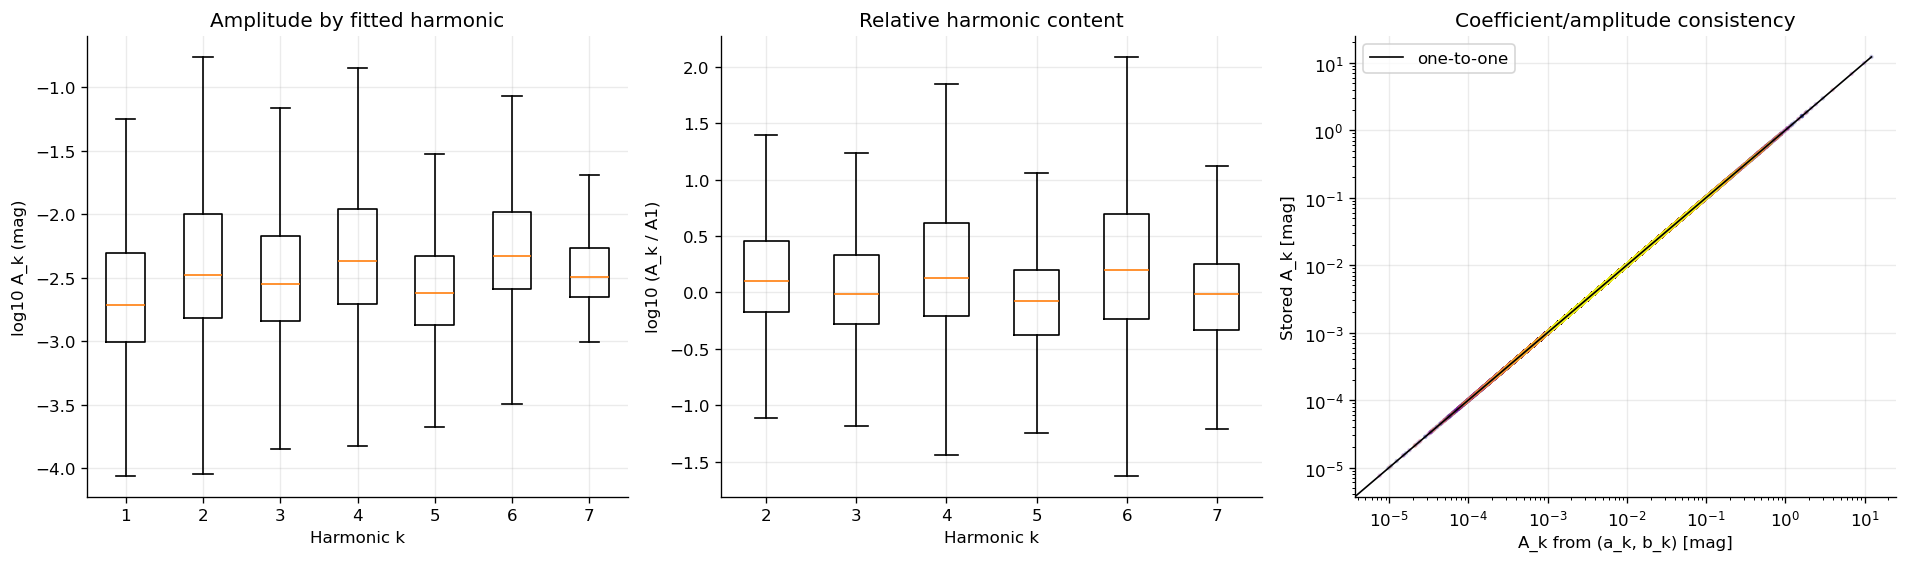

,harmonic,count,median,max
0,1,22942,0,0
1,2,20002,0,0
2,3,19264,0,0
3,4,18658,0,0
4,5,16868,0,0
5,6,15771,0,0
6,7,10568,0,0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
amp_by_k = [log10_positive(coefficient_long.loc[coefficient_long['harmonic'].eq(k), 'amplitude']) for k in HARMONIC_ORDERS]
amp_by_k = [values[np.isfinite(values)] for values in amp_by_k]
axes[0].boxplot(amp_by_k, labels=HARMONIC_ORDERS, showfliers=False)
axes[0].set(xlabel='Harmonic k', ylabel='log10 A_k (mag)', title='Amplitude by fitted harmonic')

ratio_by_k = [
    log10_positive(coefficient_long.loc[coefficient_long['harmonic'].eq(k), 'amplitude_ratio_to_A1'])
    for k in range(2, 8)
]
ratio_by_k = [values[np.isfinite(values)] for values in ratio_by_k]
axes[1].boxplot(ratio_by_k, labels=range(2, 8), showfliers=False)
axes[1].set(xlabel='Harmonic k', ylabel='log10 (A_k / A1)', title='Relative harmonic content')

contract_rows = []
for k in HARMONIC_ORDERS:
    data = fits[[f'A{k}_from_coeff', f'A{k}_stored']].dropna()
    if not data.empty:
        contract_rows.append(pd.DataFrame({'from_coeff': data[f'A{k}_from_coeff'], 'stored': data[f'A{k}_stored'], 'harmonic': k}))
contract = pd.concat(contract_rows, ignore_index=True) if contract_rows else pd.DataFrame(columns=['from_coeff', 'stored', 'harmonic'])
contract = contract.loc[(contract['from_coeff'] > 0) & (contract['stored'] > 0)]
if contract.empty:
    axes[2].text(0.5, 0.5, 'No paired stored/reconstructed amplitudes', ha='center', va='center')
else:
    axes[2].scatter(contract['from_coeff'], contract['stored'], s=3, alpha=0.18, c=contract['harmonic'], cmap='plasma')
    limit = max(contract[['from_coeff', 'stored']].max())
    axes[2].plot([0, limit], [0, limit], color='black', lw=1, label='one-to-one')
    axes[2].set(xscale='log', yscale='log', xlabel='A_k from (a_k, b_k) [mag]', ylabel='Stored A_k [mag]', title='Coefficient/amplitude consistency')
    axes[2].legend(loc='upper left')
save_show(fig, '05_harmonic_content_and_contract_check')

contract_summary = (
    contract.assign(abs_difference=lambda frame: (frame['from_coeff'] - frame['stored']).abs())
    .groupby('harmonic')['abs_difference'].agg(['count', 'median', 'max']).reset_index()
)
contract_summary.to_csv(OUTPUT_DIR / 'fourier_amplitude_contract_check.csv', index=False)
display(contract_summary)


## Fourier shape planes

$R_{k1}$ and $\phi_{k1}$ remove the arbitrary phase origin and use the first harmonic as a reference. The density maps show where the candidate population lies; they do not imply that each visual cluster is a physical class.

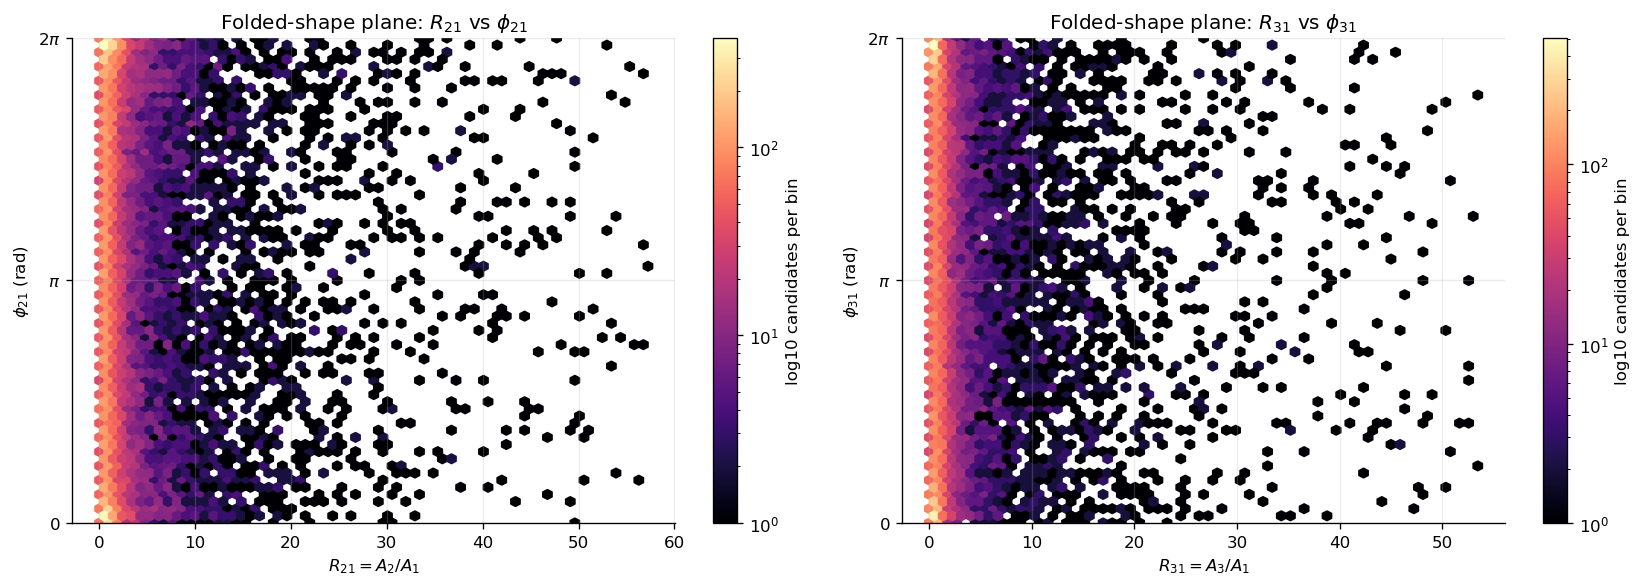

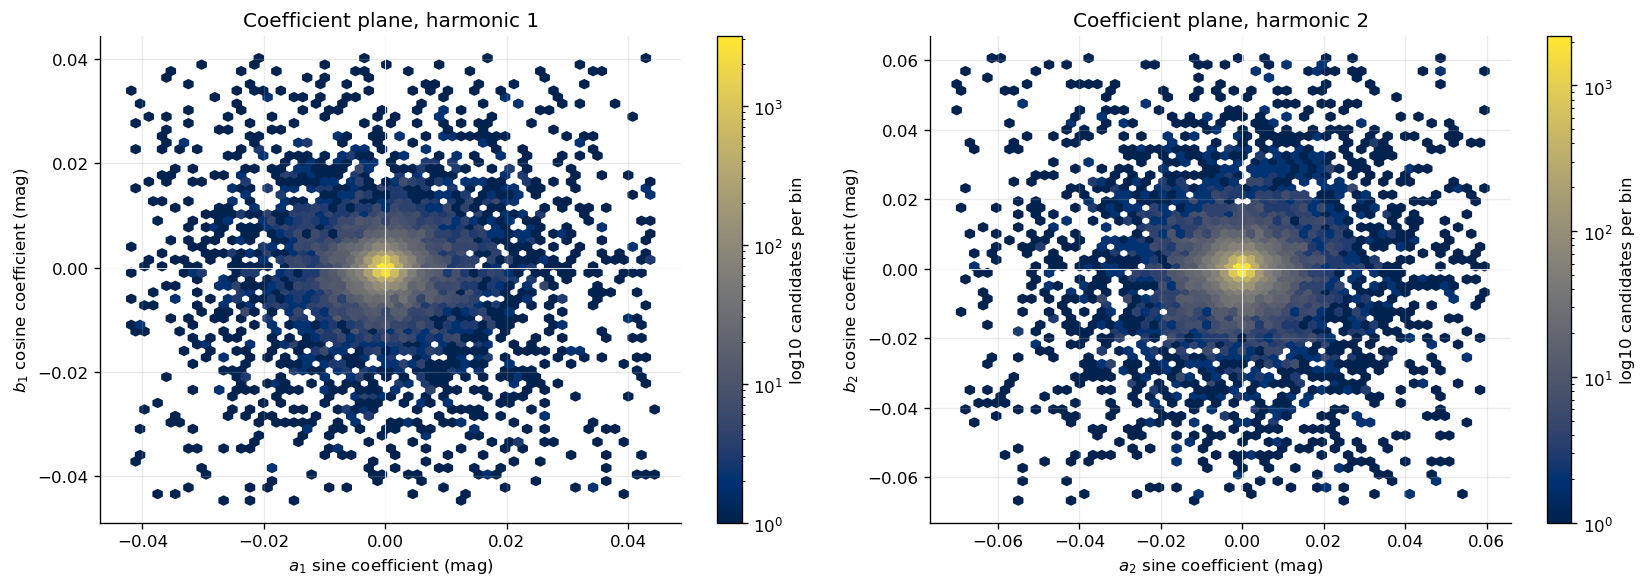

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, k in zip(axes, (2, 3)):
    ratio = f'R{k}1_from_coeff'
    phase = f'phi{k}1_from_coeff'
    data = finite_xy(fits, ratio, phase)
    # Extreme ratios usually arise when A1 is nearly zero; retain the central 99% for a readable population view.
    if not data.empty:
        lo, hi = clipped_limits(data[ratio], 0.005, 0.995)
        shown = data.loc[data[ratio].between(lo, hi)]
        hb = ax.hexbin(shown[ratio], shown[phase], gridsize=60, mincnt=1, cmap='magma', bins='log')
        fig.colorbar(hb, ax=ax, label='log10 candidates per bin')
        ax.set(xlabel=rf'$R_{{{k}1}} = A_{k}/A_1$', ylabel=rf'$\phi_{{{k}1}}$ (rad)', title=rf'Folded-shape plane: $R_{{{k}1}}$ vs $\phi_{{{k}1}}$')
        ax.set_ylim(0, 2 * np.pi)
        ax.set_yticks([0, np.pi, 2 * np.pi], ['0', r'$\pi$', r'$2\pi$'])
    else:
        ax.text(0.5, 0.5, f'No finite R{k}1 / phase values', ha='center', va='center')
save_show(fig, '06_fourier_shape_planes')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, k in zip(axes, (1, 2)):
    data = coefficient_long.loc[coefficient_long['harmonic'].eq(k), ['a', 'b']].dropna()
    if data.empty:
        ax.text(0.5, 0.5, f'No finite stored a{k}/b{k} coefficient pairs', ha='center', va='center', transform=ax.transAxes)
    else:
        lo_a, hi_a = clipped_limits(data['a'])
        lo_b, hi_b = clipped_limits(data['b'])
        shown = data.loc[data['a'].between(lo_a, hi_a) & data['b'].between(lo_b, hi_b)]
        hb = ax.hexbin(shown['a'], shown['b'], gridsize=60, mincnt=1, cmap='cividis', bins='log')
        fig.colorbar(hb, ax=ax, label='log10 candidates per bin')
        ax.axhline(0, color='white', lw=0.6, alpha=0.8)
        ax.axvline(0, color='white', lw=0.6, alpha=0.8)
    ax.set(xlabel=rf'$a_{k}$ sine coefficient (mag)', ylabel=rf'$b_{k}$ cosine coefficient (mag)', title=rf'Coefficient plane, harmonic {k}')
save_show(fig, '07_coefficient_planes')


## Available Review-class context

`event_class` is current human-review state, not training truth and not a complete taxonomy for the 22k population. This panel therefore reports fit coverage and selected order only for the most populated available classes.

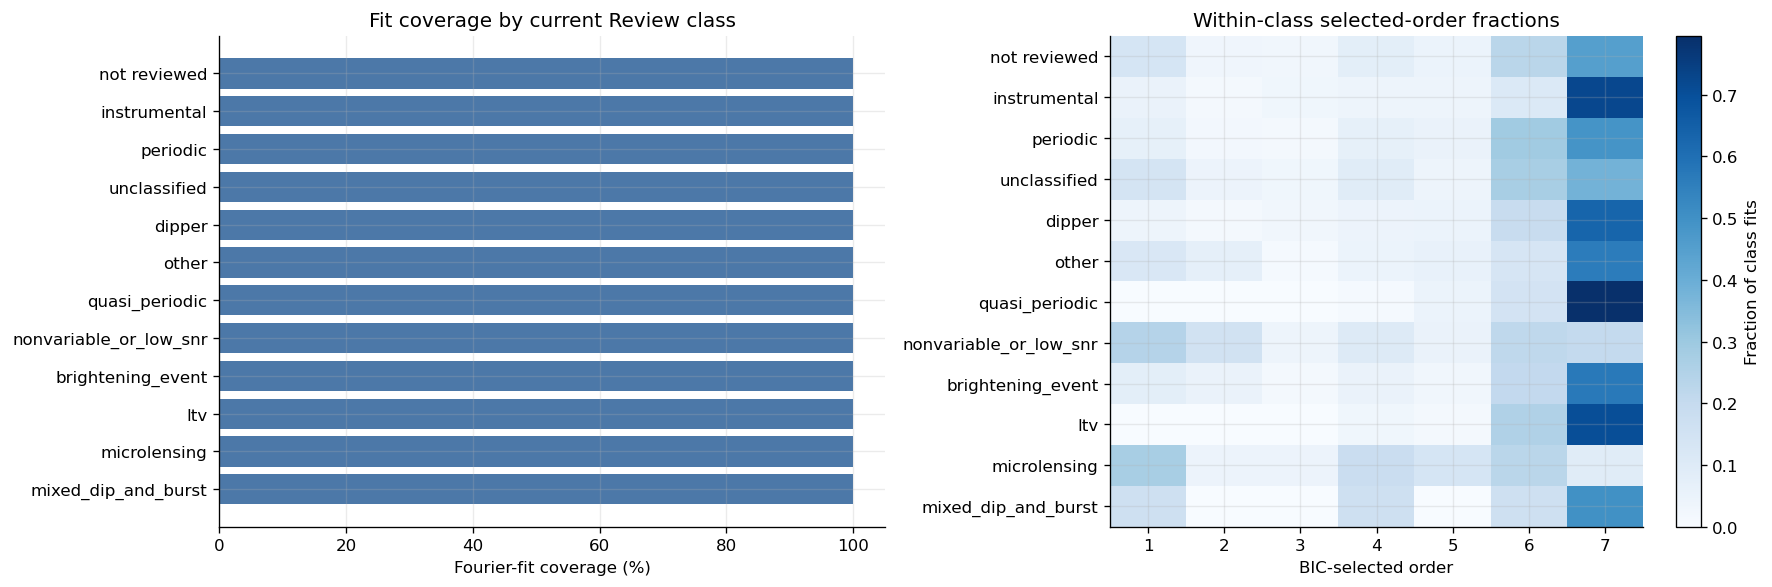

,event_class,n_population,n_with_fourier_fit,fit_fraction
0,not reviewed,20527,20527,1
1,instrumental,669,669,1
2,periodic,659,659,1
3,unclassified,477,477,1
4,dipper,182,182,1
5,other,84,84,1
6,quasi_periodic,83,83,1
7,nonvariable_or_low_snr,79,79,1
8,brightening_event,77,77,1
9,ltv,71,71,1


In [9]:
class_sizes = population['event_class_display'].value_counts()
shown_classes = class_sizes.head(MAX_PLOT_CLASSES).index.tolist()
class_summary = pd.DataFrame({'event_class': shown_classes, 'n_population': class_sizes.loc[shown_classes].to_numpy()})
class_fit_counts = fits['event_class_display'].value_counts()
class_summary['n_with_fourier_fit'] = class_summary['event_class'].map(class_fit_counts).fillna(0).astype(int)
class_summary['fit_fraction'] = class_summary['n_with_fourier_fit'] / class_summary['n_population']
class_summary.to_csv(OUTPUT_DIR / 'fourier_by_review_class.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ordered = class_summary.sort_values('n_population')
axes[0].barh(ordered['event_class'], ordered['fit_fraction'] * 100, color='#4c78a8')
axes[0].set(xlabel='Fourier-fit coverage (%)', xlim=(0, 105), title='Fit coverage by current Review class')

order_by_class = pd.crosstab(fits['event_class_display'], fits['harmonic_order']).reindex(index=shown_classes, columns=HARMONIC_ORDERS, fill_value=0)
order_by_class = order_by_class.div(order_by_class.sum(axis=1).replace(0, np.nan), axis=0)
image = axes[1].imshow(order_by_class.to_numpy(), aspect='auto', cmap='Blues', vmin=0, vmax=np.nanmax(order_by_class.to_numpy()))
axes[1].set(xticks=np.arange(7), xticklabels=HARMONIC_ORDERS, yticks=np.arange(len(order_by_class)), yticklabels=order_by_class.index, xlabel='BIC-selected order', title='Within-class selected-order fractions')
fig.colorbar(image, ax=axes[1], label='Fraction of class fits')
save_show(fig, '08_review_class_context')
display(class_summary.sort_values('n_population', ascending=False))


## Representative Fourier model curves

These are the stored Fourier models, not interpolations through observed data. They make it easy to inspect the kinds of shapes selected by the fit. The `poor_fit` example is included specifically to show that a visually structured Fourier model can still be an inadequate description of the underlying folded measurements.

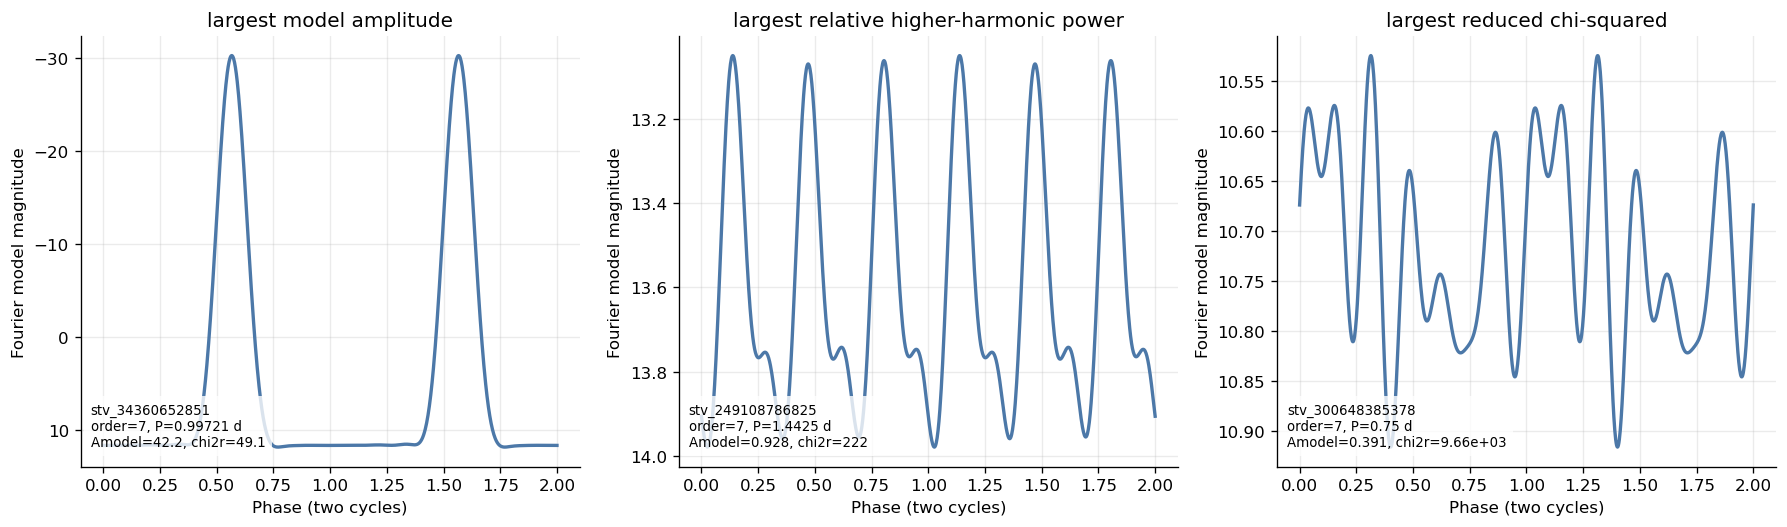

,candidate_id,selection_reason,event_class_display,harmonic_order,period_days,model_amplitude,reduced_chi2,A1,relative_higher_harmonic_power
9891,stv_34360652851,largest model amplitude,not reviewed,7,0.9972,42.19,49.07,12.22,1.903
8981,stv_249108786825,largest relative higher-harmonic power,not reviewed,7,1.443,0.9281,221.6,0.0003858,"1,469"
20331,stv_300648385378,largest reduced chi-squared,not reviewed,7,0.75,0.3908,"9,665",0.06483,4.098


In [10]:
def first_valid(frame: pd.DataFrame, sort_column: str, ascending: bool, label: str, extra_mask: pd.Series | None = None) -> pd.Series | None:
    subset = frame.copy() if extra_mask is None else frame.loc[extra_mask].copy()
    subset = subset.loc[np.isfinite(subset[sort_column])]
    if subset.empty:
        return None
    row = subset.sort_values(sort_column, ascending=ascending).iloc[0].copy()
    row['selection_reason'] = label
    return row

complexity = fits[[f'A{k}' for k in range(2, 8)]].sum(axis=1, min_count=1) / fits['A1'].where(fits['A1'].gt(0))
fits['relative_higher_harmonic_power'] = complexity
model_ready = np.isfinite(fits['a0'])
for k in HARMONIC_ORDERS:
    a = fits.get(f'stats_harmonics_a{k}', pd.Series(np.nan, index=fits.index))
    b = fits.get(f'stats_harmonics_b{k}', pd.Series(np.nan, index=fits.index))
    model_ready &= fits['harmonic_order'].lt(k) | (np.isfinite(a) & np.isfinite(b))
model_fits = fits.loc[model_ready].copy()
selections = [
    first_valid(model_fits, 'model_amplitude', False, 'largest model amplitude'),
    first_valid(model_fits, 'relative_higher_harmonic_power', False, 'largest relative higher-harmonic power'),
    first_valid(model_fits, 'reduced_chi2', False, 'largest reduced chi-squared'),
    first_valid(model_fits, 'A1', False, 'largest A1', model_fits['harmonic_order'].eq(7)),
]
representatives = pd.DataFrame([row for row in selections if row is not None]).drop_duplicates('candidate_id')
if representatives.empty:
    representatives = model_fits.head(0).copy()
    representatives['selection_reason'] = pd.Series(dtype='string')

def evaluate_fourier_model(row: pd.Series, phase: np.ndarray) -> np.ndarray:
    model = np.full_like(phase, float(row['a0']), dtype=float)
    for k in HARMONIC_ORDERS:
        if int(row['harmonic_order']) < k:
            break
        a = float(row[f'stats_harmonics_a{k}'])
        b = float(row[f'stats_harmonics_b{k}'])
        model += a * np.sin(2 * np.pi * k * phase) + b * np.cos(2 * np.pi * k * phase)
    return model

phase_grid = np.linspace(0, 2, 1000)
fig, axes = plt.subplots(1, max(len(representatives), 1), figsize=(5 * max(len(representatives), 1), 4.5), squeeze=False)
for ax, (_, row) in zip(axes.ravel(), representatives.iterrows()):
    model = evaluate_fourier_model(row, phase_grid)
    ax.plot(phase_grid, model, color='#4c78a8', lw=2)
    ax.invert_yaxis()
    ax.set(xlabel='Phase (two cycles)', ylabel='Fourier model magnitude', title=str(row['selection_reason']))
    ax.text(0.02, 0.04, f"{row['candidate_id']}\norder={int(row['harmonic_order'])}, P={row['period_days']:.5g} d\nAmodel={row['model_amplitude']:.3g}, chi2r={row['reduced_chi2']:.3g}", transform=ax.transAxes, va='bottom', fontsize=8, bbox={'facecolor': 'white', 'alpha': 0.8, 'edgecolor': 'none'})
for ax in axes.ravel()[len(representatives):]:
    ax.axis('off')
save_show(fig, '09_representative_fourier_models')

representatives[[column for column in ['candidate_id', 'selection_reason', 'event_class_display', 'harmonic_order', 'period_days', 'model_amplitude', 'reduced_chi2', 'A1', 'relative_higher_harmonic_power'] if column in representatives]].to_csv(OUTPUT_DIR / 'fourier_representative_models.csv', index=False)
display(representatives[[column for column in ['candidate_id', 'selection_reason', 'event_class_display', 'harmonic_order', 'period_days', 'model_amplitude', 'reduced_chi2', 'A1', 'relative_higher_harmonic_power'] if column in representatives]])


## External ASAS-SN semiregular-variable cohort

This section independently selects candidates whose matched external ASAS-SN variable-catalog type contains a semiregular token: `SR`, `SRA`, `SRB`, `SRC`, `SRD`, `SRS`, or literal `SRV`. It uses MALCA's catalog-class tokenizer, so compound and colon-marked types are handled consistently. The selection uses only `candidates.asassn_var_type`—not Review labels, Fourier properties, or model scores.

In [11]:
SRV_TOKENS = frozenset({'SR', 'SRA', 'SRB', 'SRC', 'SRD', 'SRS', 'SRV'})

for column in ('asassn_var_name', 'asassn_var_type'):
    if column not in population:
        population[column] = pd.Series(pd.NA, index=population.index, dtype='string')
if 'asassn_var_period' not in population:
    population['asassn_var_period'] = np.nan

population['asassn_var_tokens'] = population['asassn_var_type'].map(
    lambda value: tuple(tokenize_catalog_classes(value))
)
population['is_asassn_srv'] = population['asassn_var_tokens'].map(
    lambda tokens: bool(set(tokens) & SRV_TOKENS)
)
srv_population = population.loc[population['is_asassn_srv']].copy()
srv_ids = set(srv_population['candidate_id'])
srv_fits = fits.loc[fits['candidate_id'].isin(srv_ids)].copy()
srv_coeff_long = coefficient_long.loc[coefficient_long['candidate_id'].isin(srv_ids)].copy()
srv_model_fits = model_fits.loc[model_fits['candidate_id'].isin(srv_ids)].copy()

has_catalog_type = population['asassn_var_type'].fillna('').astype(str).str.strip().ne('')
srv_has_catalog_period = np.isfinite(srv_population['asassn_var_period']) & srv_population['asassn_var_period'].gt(0)
srv_coverage = pd.DataFrame({
    'quantity': [
        'all candidate rows',
        'candidates with an ASAS-SN variable-catalog type',
        'ASAS-SN catalog semiregular variables',
        'ASAS-SN SRVs with a valid Fourier fit',
        'ASAS-SN SRVs with a positive catalog period',
    ],
    'count': [
        len(population),
        int(has_catalog_type.sum()),
        len(srv_population),
        len(srv_fits),
        int(srv_has_catalog_period.sum()),
    ],
})
srv_coverage['fraction_of_all_candidates'] = srv_coverage['count'] / len(population)
srv_coverage['fraction_of_srv_cohort'] = np.nan
if len(srv_population):
    srv_coverage.loc[2:, 'fraction_of_srv_cohort'] = srv_coverage.loc[2:, 'count'] / len(srv_population)

srv_type_counts = (
    srv_population['asassn_var_type'].fillna('missing').value_counts()
    .rename_axis('asassn_var_type').reset_index(name='n_candidates')
)
fit_export_columns = [
    'candidate_id', 'harmonic_order', 'period_days', 'model_amplitude', 'reduced_chi2',
    'A1', 'R21', 'phi21', 'R31', 'phi31', 'relative_higher_harmonic_power',
]
srv_export = srv_population[[
    'candidate_id', 'asas_sn_id', 'asassn_var_name', 'asassn_var_type',
    'asassn_var_period', 'event_class_display',
]].merge(
    srv_fits[[column for column in fit_export_columns if column in srv_fits]],
    on='candidate_id', how='left', validate='one_to_one',
)
srv_export.to_csv(OUTPUT_DIR / 'asassn_srv_candidates_fourier.csv', index=False)
srv_coverage.to_csv(OUTPUT_DIR / 'asassn_srv_fourier_coverage.csv', index=False)
srv_type_counts.to_csv(OUTPUT_DIR / 'asassn_srv_catalog_type_counts.csv', index=False)

display(Markdown(
    f'**ASAS-SN semiregular cohort:** {len(srv_population):,} candidates; '
    f'{len(srv_fits):,} ({len(srv_fits) / len(srv_population):.1%}) have valid stored Fourier fits.'
    if len(srv_population) else '**ASAS-SN semiregular cohort:** no matching candidates.'
))
display(srv_coverage)
display(srv_type_counts)


**ASAS-SN semiregular cohort:** 759 candidates; 759 (100.0%) have valid stored Fourier fits.

,quantity,count,fraction_of_all_candidates,fraction_of_srv_cohort
0,all candidate rows,22942,1,NaN
1,candidates with an ASAS-SN variable-catalog type,15593,0.6797,NaN
2,ASAS-SN catalog semiregular variables,759,0.03308,1
3,ASAS-SN SRVs with a valid Fourier fit,759,0.03308,1
4,ASAS-SN SRVs with a positive catalog period,750,0.03269,0.9881


,asassn_var_type,n_candidates
0,SR,759


### SRV Fourier coverage, selected order, and scalar diagnostics

The full-population distributions provide context; the red distributions are the independently catalog-selected SRVs. Fractions are normalized within each cohort so the large difference in cohort size does not dominate the order comparison.

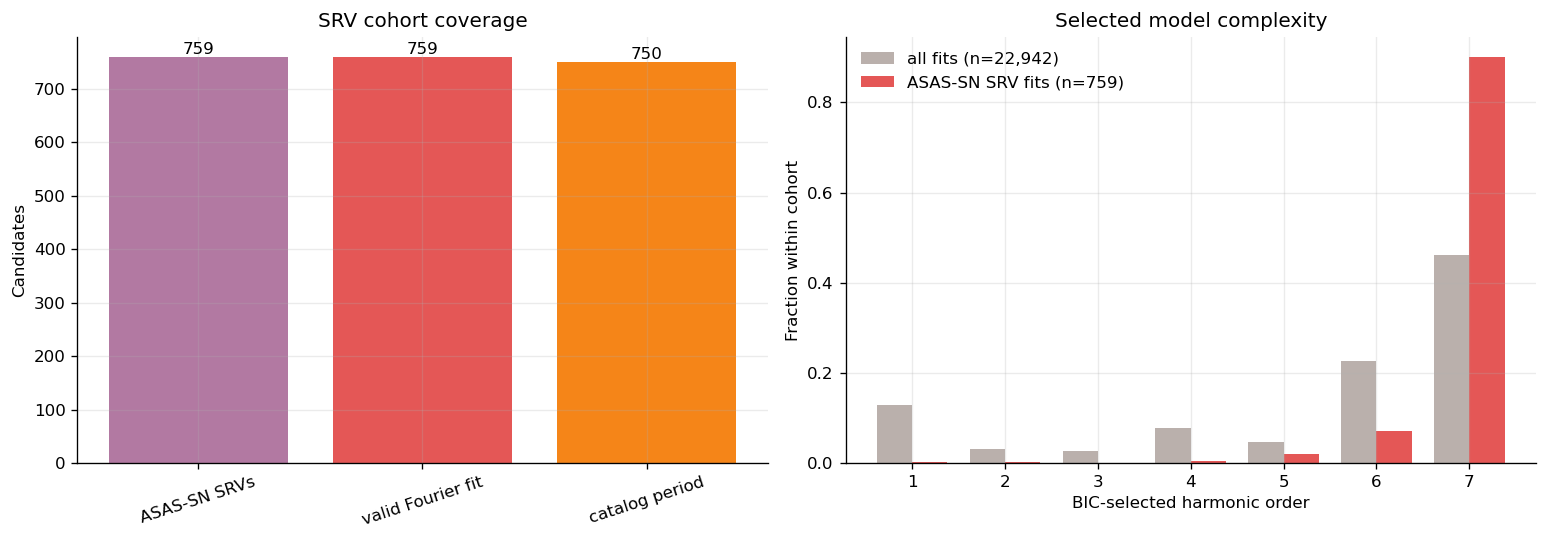

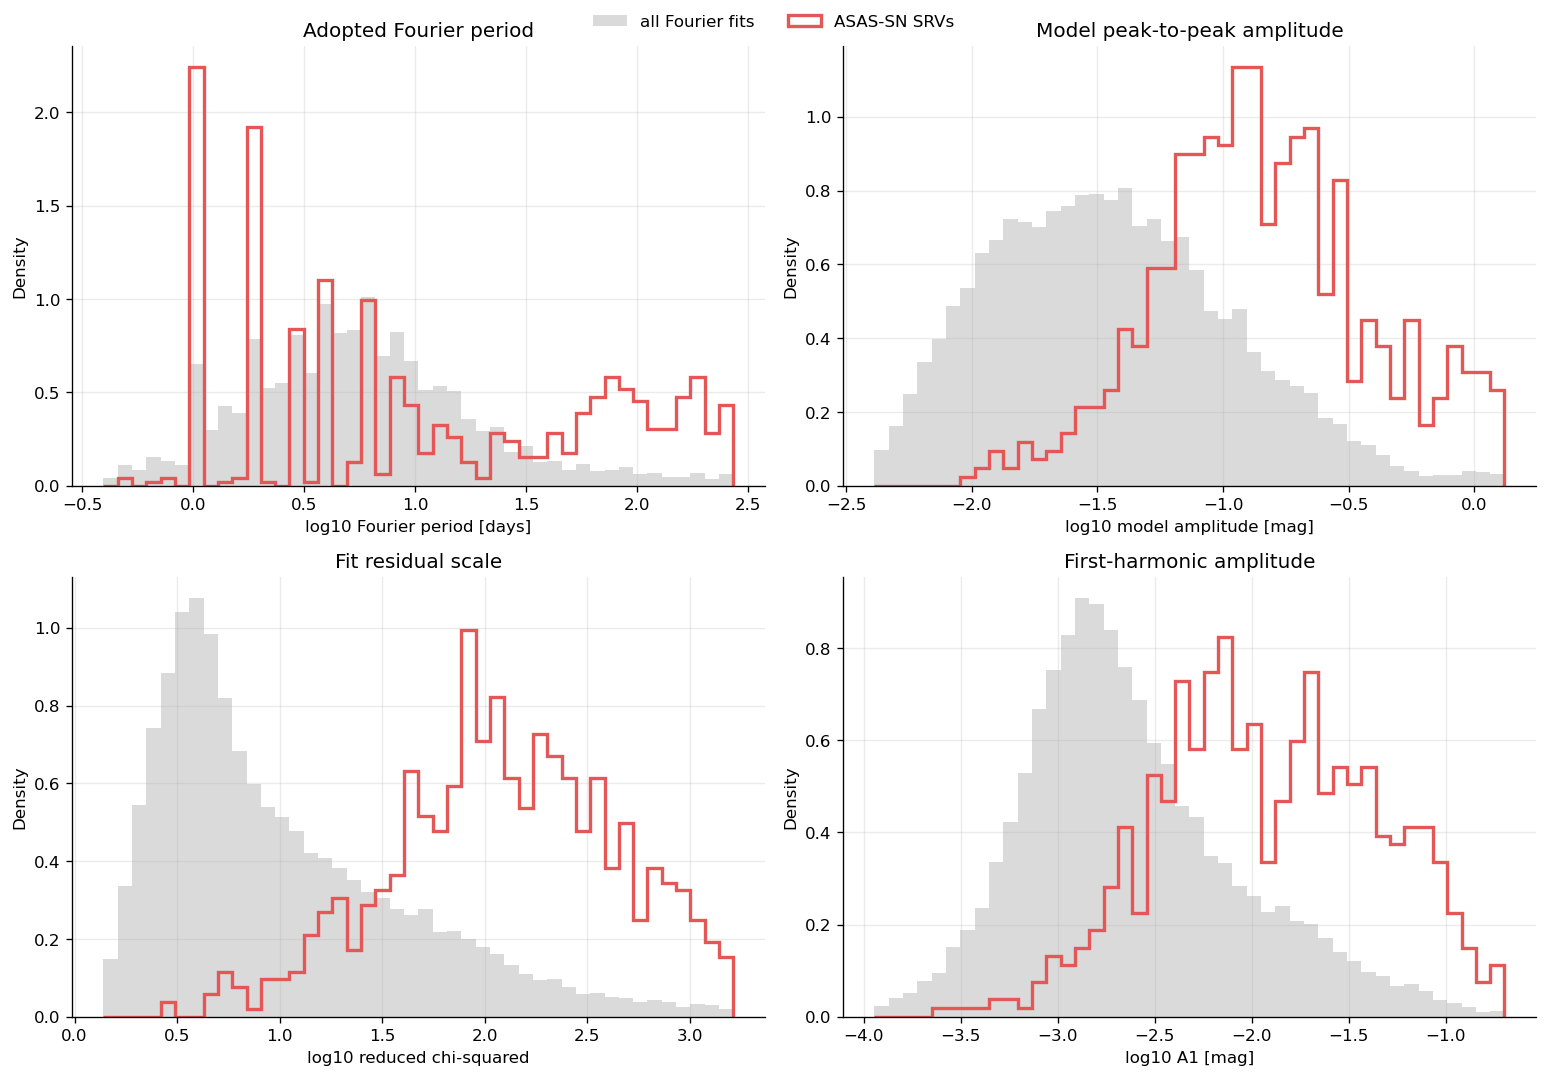

,harmonic_order,n_candidates,fraction_of_srv_fits
0,1,2,0.002635
1,2,1,0.001318
2,3,0,0
3,4,3,0.003953
4,5,16,0.02108
5,6,54,0.07115
6,7,683,0.8999


In [12]:
srv_order_counts = (
    srv_fits['harmonic_order'].value_counts().reindex(HARMONIC_ORDERS, fill_value=0)
    .rename_axis('harmonic_order').reset_index(name='n_candidates')
)
srv_order_counts['fraction_of_srv_fits'] = (
    srv_order_counts['n_candidates'] / len(srv_fits) if len(srv_fits) else np.nan
)
srv_order_counts.to_csv(OUTPUT_DIR / 'asassn_srv_fourier_order_counts.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
stages = ['ASAS-SN SRVs', 'valid Fourier fit', 'catalog period']
stage_counts = [len(srv_population), len(srv_fits), int(srv_has_catalog_period.sum())]
axes[0].bar(stages, stage_counts, color=['#b279a2', '#e45756', '#f58518'])
axes[0].set(ylabel='Candidates', title='SRV cohort coverage')
axes[0].tick_params(axis='x', rotation=18)
for position, count in enumerate(stage_counts):
    axes[0].text(position, count, f'{count:,}', ha='center', va='bottom')

orders = np.asarray(HARMONIC_ORDERS)
all_fraction = order_counts.set_index('harmonic_order')['fraction_of_fits'].reindex(HARMONIC_ORDERS).to_numpy()
srv_fraction = srv_order_counts.set_index('harmonic_order')['fraction_of_srv_fits'].reindex(HARMONIC_ORDERS).to_numpy()
axes[1].bar(orders - 0.19, all_fraction, width=0.38, color='#bab0ac', label=f'all fits (n={len(fits):,})')
axes[1].bar(orders + 0.19, srv_fraction, width=0.38, color='#e45756', label=f'ASAS-SN SRV fits (n={len(srv_fits):,})')
axes[1].set(xlabel='BIC-selected harmonic order', ylabel='Fraction within cohort', title='Selected model complexity', xticks=orders)
axes[1].legend(frameon=False)
save_show(fig, '10_asassn_srv_coverage_and_order')

def overlay_log_hist(ax: plt.Axes, all_values: pd.Series, srv_values: pd.Series, xlabel: str, title: str) -> None:
    all_logged = log10_positive(all_values)
    srv_logged = log10_positive(srv_values)
    all_logged = all_logged[np.isfinite(all_logged)]
    srv_logged = srv_logged[np.isfinite(srv_logged)]
    if all_logged.size:
        lo, hi = np.quantile(all_logged, [0.005, 0.995])
        if not np.isfinite(lo) or not np.isfinite(hi) or lo == hi:
            lo, hi = clipped_limits(all_logged, 0.0, 1.0)
        bins = np.linspace(lo, hi, 45)
        ax.hist(all_logged, bins=bins, density=True, histtype='stepfilled', alpha=0.32, color='#8c8c8c', label='all Fourier fits')
        in_range = srv_logged[(srv_logged >= lo) & (srv_logged <= hi)]
        if in_range.size:
            ax.hist(in_range, bins=bins, density=True, histtype='step', lw=2, color='#e45756', label='ASAS-SN SRVs')
    else:
        ax.text(0.5, 0.5, 'No positive finite values', ha='center', va='center', transform=ax.transAxes)
    ax.set(xlabel=xlabel, ylabel='Density', title=title)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
overlay_log_hist(axes[0, 0], fits['period_days'], srv_fits['period_days'], 'log10 Fourier period [days]', 'Adopted Fourier period')
overlay_log_hist(axes[0, 1], fits['model_amplitude'], srv_fits['model_amplitude'], 'log10 model amplitude [mag]', 'Model peak-to-peak amplitude')
overlay_log_hist(axes[1, 0], fits['reduced_chi2'], srv_fits['reduced_chi2'], 'log10 reduced chi-squared', 'Fit residual scale')
overlay_log_hist(axes[1, 1], fits['A1'], srv_fits['A1'], 'log10 A1 [mag]', 'First-harmonic amplitude')
handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
save_show(fig, '11_asassn_srv_scalar_comparison')
display(srv_order_counts)


### ASAS-SN catalog period versus MALCA Fourier period

Semiregular variability can be multiperiodic and irregular, and survey cadences can prefer aliases. The comparison therefore reports both direct agreement and proximity to common integer or subharmonic ratios; it does not assume the catalog period is uniquely correct.

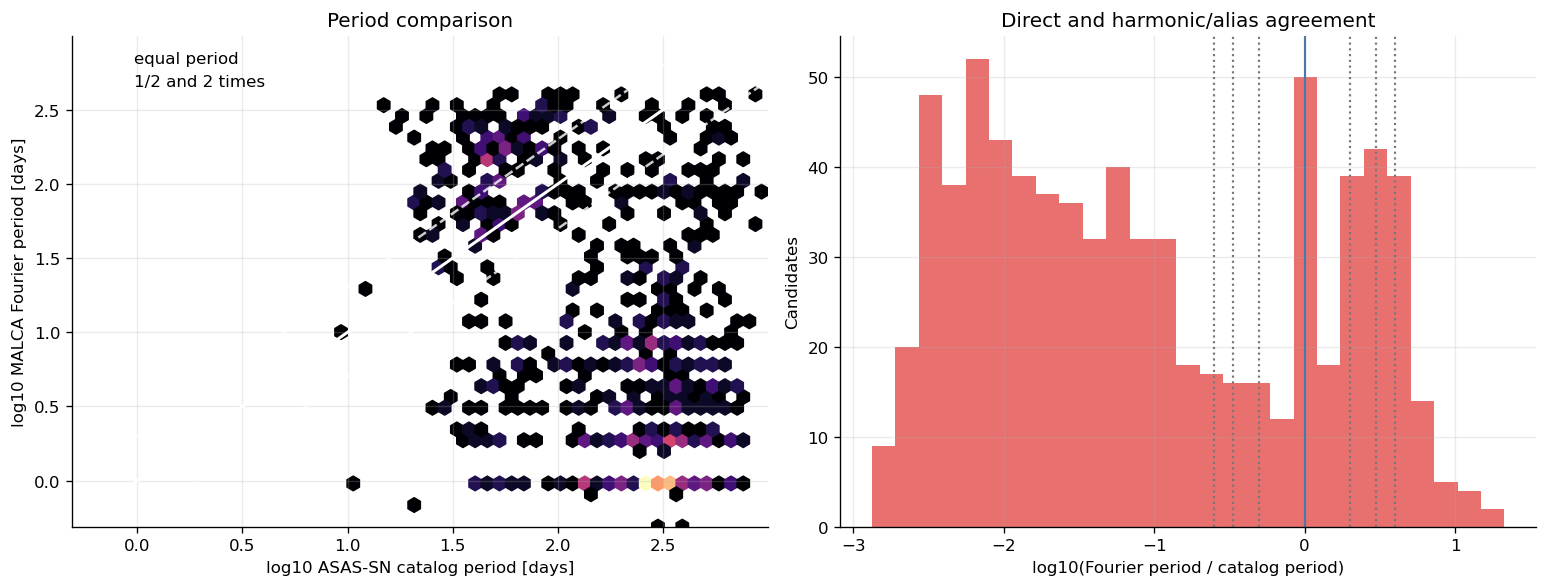

,metric,value
0,SRVs with both periods,750
1,median Fourier/catalog ratio,0.05551
2,within 10% of equal period,0.06267
3,within 10% of listed alias factor,0.232


In [13]:
srv_periods = srv_fits.loc[
    np.isfinite(srv_fits['period_days']) & srv_fits['period_days'].gt(0)
    & np.isfinite(srv_fits['asassn_var_period']) & srv_fits['asassn_var_period'].gt(0),
    ['candidate_id', 'asassn_var_name', 'asassn_var_type', 'asassn_var_period', 'period_days', 'harmonic_order', 'model_amplitude', 'reduced_chi2'],
].copy()
srv_periods['fourier_to_catalog_period_ratio'] = srv_periods['period_days'] / srv_periods['asassn_var_period']
alias_factors = np.asarray([0.25, 1 / 3, 0.5, 1.0, 2.0, 3.0, 4.0])
if len(srv_periods):
    ratio_matrix = srv_periods['fourier_to_catalog_period_ratio'].to_numpy()[:, None] / alias_factors[None, :]
    alias_distance = np.abs(np.log(ratio_matrix))
    closest_index = np.argmin(alias_distance, axis=1)
    srv_periods['closest_alias_factor'] = alias_factors[closest_index]
    srv_periods['fractional_distance_from_alias'] = np.expm1(alias_distance[np.arange(len(srv_periods)), closest_index])
else:
    srv_periods['closest_alias_factor'] = np.nan
    srv_periods['fractional_distance_from_alias'] = np.nan

period_summary = pd.DataFrame({
    'metric': ['SRVs with both periods', 'median Fourier/catalog ratio', 'within 10% of equal period', 'within 10% of listed alias factor'],
    'value': [
        len(srv_periods),
        srv_periods['fourier_to_catalog_period_ratio'].median() if len(srv_periods) else np.nan,
        np.mean(np.abs(np.log(srv_periods['fourier_to_catalog_period_ratio'])) <= np.log(1.1)) if len(srv_periods) else np.nan,
        np.mean(srv_periods['fractional_distance_from_alias'] <= 0.1) if len(srv_periods) else np.nan,
    ],
})
srv_periods.to_csv(OUTPUT_DIR / 'asassn_srv_period_comparison.csv', index=False)
period_summary.to_csv(OUTPUT_DIR / 'asassn_srv_period_summary.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
if len(srv_periods):
    catalog_log = np.log10(srv_periods['asassn_var_period'])
    fourier_log = np.log10(srv_periods['period_days'])
    axes[0].hexbin(catalog_log, fourier_log, gridsize=35, mincnt=1, cmap='magma')
    lo = min(catalog_log.min(), fourier_log.min())
    hi = max(catalog_log.max(), fourier_log.max())
    axes[0].plot([lo, hi], [lo, hi], color='white', lw=1.8, label='equal period')
    axes[0].plot([lo, hi], [lo + np.log10(0.5), hi + np.log10(0.5)], color='white', ls='--', alpha=0.8, label='1/2 and 2 times')
    axes[0].plot([lo, hi], [lo + np.log10(2), hi + np.log10(2)], color='white', ls='--', alpha=0.8)
    axes[0].set_xlim(lo, hi)
    axes[0].set_ylim(lo, hi)
    ratio_log = np.log10(srv_periods['fourier_to_catalog_period_ratio'])
    axes[1].hist(ratio_log, bins=min(50, max(12, int(np.sqrt(len(ratio_log))))), color='#e45756', alpha=0.85)
    for factor in alias_factors:
        axes[1].axvline(np.log10(factor), color='#4c78a8' if factor == 1 else '#777777', lw=1.3, ls='-' if factor == 1 else ':')
else:
    for ax in axes:
        ax.text(0.5, 0.5, 'No SRVs have both positive periods', ha='center', va='center', transform=ax.transAxes)
axes[0].set(xlabel='log10 ASAS-SN catalog period [days]', ylabel='log10 MALCA Fourier period [days]', title='Period comparison')
axes[0].legend(frameon=False)
axes[1].set(xlabel='log10(Fourier period / catalog period)', ylabel='Candidates', title='Direct and harmonic/alias agreement')
save_show(fig, '12_asassn_srv_period_comparison')
display(period_summary)


### SRV Fourier shape planes and harmonic profile

The shape planes show only catalog-selected SRVs. The harmonic profile then compares their median relative amplitudes with the full fitted population; ribbons span the 16th–84th percentiles among objects whose selected model contains that harmonic.

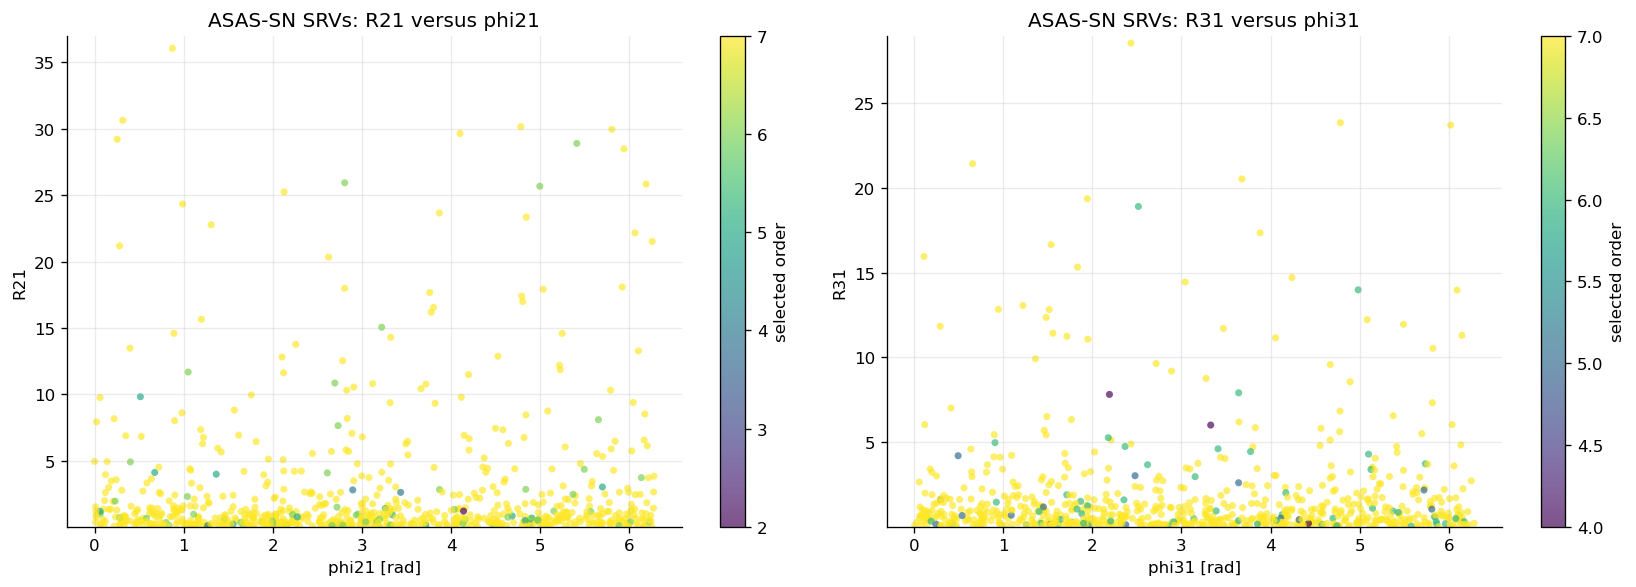

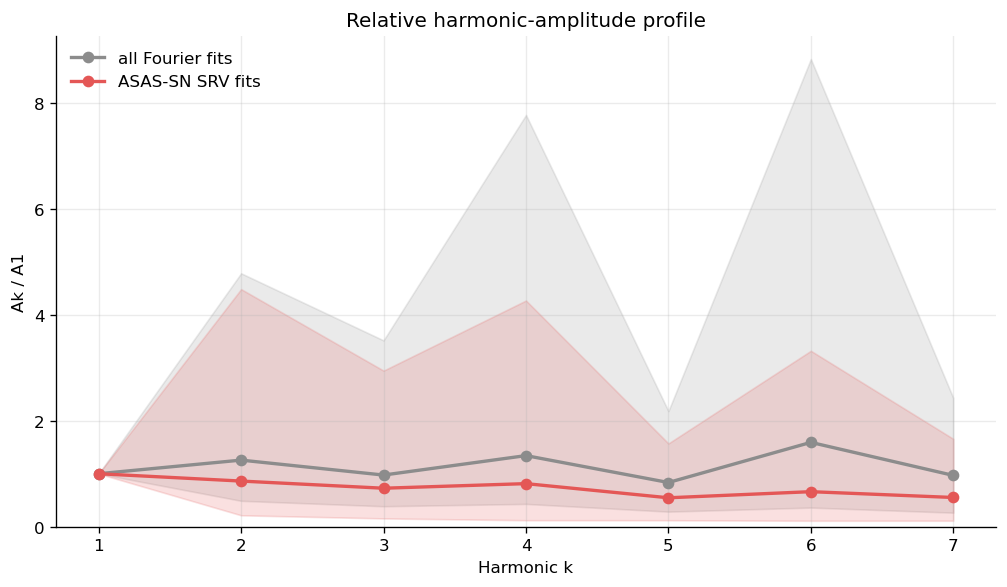

,cohort,harmonic,n_candidates,p16_Ak_over_A1,median_Ak_over_A1,p84_Ak_over_A1
0,all Fourier fits,1,22942,1,1,1
1,all Fourier fits,2,20002,0.4883,1.257,4.785
2,all Fourier fits,3,19264,0.3856,0.9747,3.518
3,all Fourier fits,4,18658,0.4295,1.342,7.775
4,all Fourier fits,5,16868,0.2838,0.8341,2.183
5,all Fourier fits,6,15771,0.3606,1.592,8.831
6,all Fourier fits,7,10568,0.2643,0.9683,2.431
7,ASAS-SN SRV fits,1,759,1,1,1
8,ASAS-SN SRV fits,2,757,0.2147,0.8612,4.486
9,ASAS-SN SRV fits,3,756,0.1554,0.7261,2.947


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ratio_column, phase_column, order_required in [
    (axes[0], 'R21', 'phi21', 2),
    (axes[1], 'R31', 'phi31', 3),
]:
    shape = srv_fits.loc[
        srv_fits['harmonic_order'].ge(order_required)
        & np.isfinite(srv_fits[ratio_column]) & np.isfinite(srv_fits[phase_column]),
        [ratio_column, phase_column, 'harmonic_order'],
    ]
    if len(shape):
        points = ax.scatter(shape[phase_column], shape[ratio_column], c=shape['harmonic_order'], cmap='viridis', s=18, alpha=0.68, linewidths=0)
        fig.colorbar(points, ax=ax, label='selected order')
        ax.set_ylim(*clipped_limits(shape[ratio_column], 0.0, 0.99))
    else:
        ax.text(0.5, 0.5, 'No finite SRV shape pairs', ha='center', va='center', transform=ax.transAxes)
    ax.set(xlabel=phase_column + ' [rad]', ylabel=ratio_column, title=f'ASAS-SN SRVs: {ratio_column} versus {phase_column}')
save_show(fig, '13_asassn_srv_fourier_shape_planes')

def harmonic_profile(frame: pd.DataFrame, cohort: str) -> pd.DataFrame:
    rows = []
    for k in HARMONIC_ORDERS:
        ratio = frame[f'A{k}'] / frame['A1'].where(frame['A1'].gt(0))
        ratio = ratio.loc[frame['harmonic_order'].ge(k) & np.isfinite(ratio)]
        rows.append({
            'cohort': cohort,
            'harmonic': k,
            'n_candidates': len(ratio),
            'p16_Ak_over_A1': ratio.quantile(0.16) if len(ratio) else np.nan,
            'median_Ak_over_A1': ratio.median() if len(ratio) else np.nan,
            'p84_Ak_over_A1': ratio.quantile(0.84) if len(ratio) else np.nan,
        })
    return pd.DataFrame(rows)

srv_harmonic_profile = pd.concat([
    harmonic_profile(fits, 'all Fourier fits'),
    harmonic_profile(srv_fits, 'ASAS-SN SRV fits'),
], ignore_index=True)
srv_harmonic_profile.to_csv(OUTPUT_DIR / 'asassn_srv_harmonic_profile.csv', index=False)

fig, ax = plt.subplots(figsize=(8.5, 5))
for cohort, color in [('all Fourier fits', '#8c8c8c'), ('ASAS-SN SRV fits', '#e45756')]:
    profile = srv_harmonic_profile.loc[srv_harmonic_profile['cohort'].eq(cohort)]
    ax.plot(profile['harmonic'], profile['median_Ak_over_A1'], marker='o', lw=2, color=color, label=cohort)
    ax.fill_between(profile['harmonic'], profile['p16_Ak_over_A1'], profile['p84_Ak_over_A1'], color=color, alpha=0.18)
ax.set(xlabel='Harmonic k', ylabel='Ak / A1', title='Relative harmonic-amplitude profile', xticks=HARMONIC_ORDERS)
ax.set_ylim(bottom=0)
ax.legend(frameon=False)
save_show(fig, '14_asassn_srv_harmonic_profile')
display(srv_harmonic_profile)


### Representative SRV Fourier model curves

These are deterministic inspection examples within the external catalog-SRV cohort: the largest amplitude, strongest relative higher-harmonic content, poorest reduced chi-squared, and closest ASAS-SN/MALCA period match. They are model curves rather than the underlying observations.

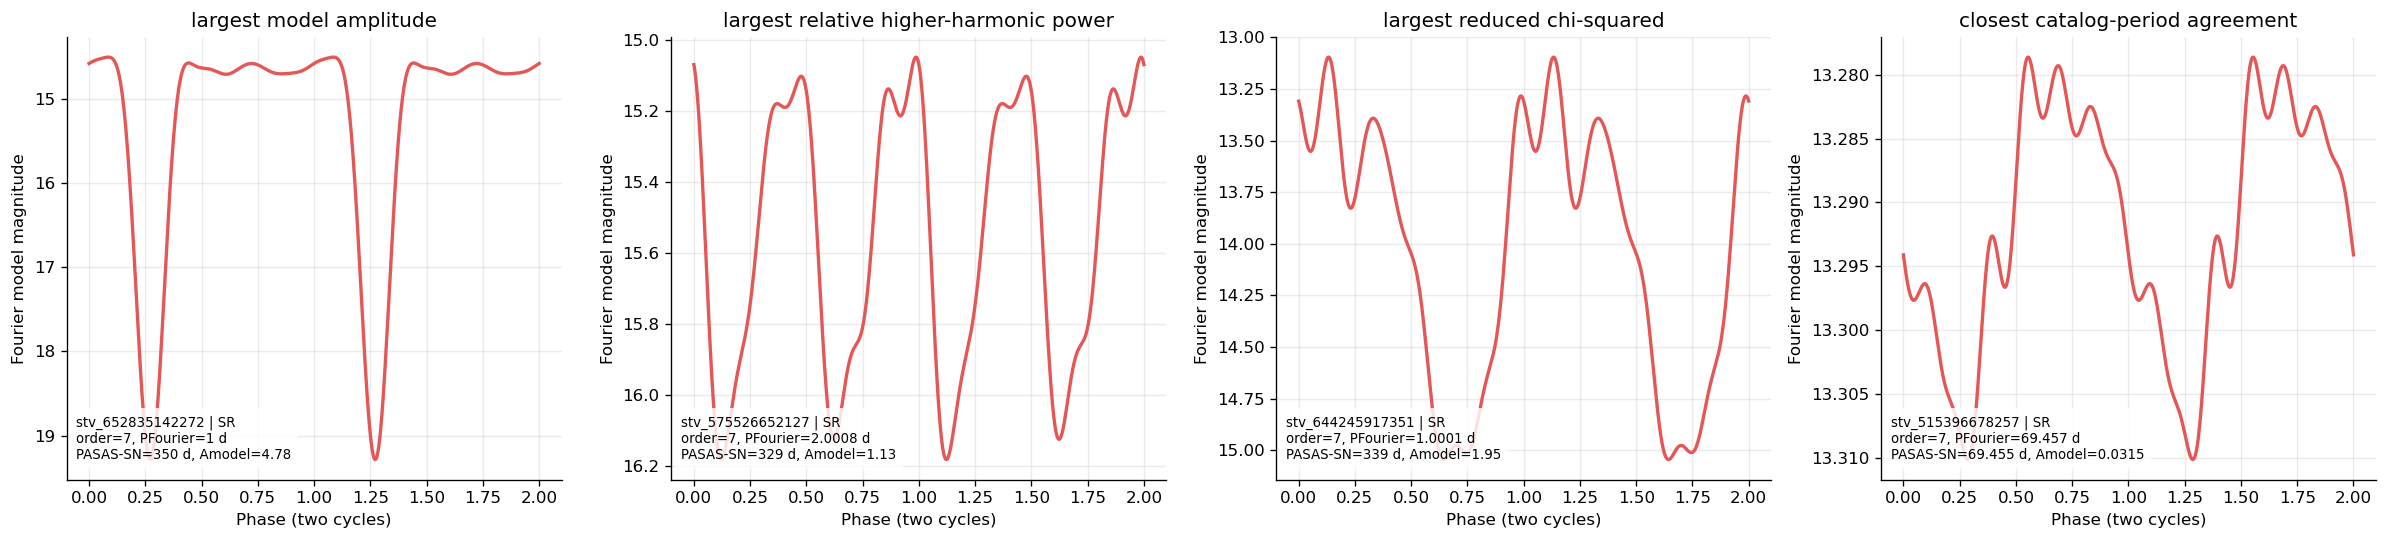

,candidate_id,asassn_var_name,asassn_var_type,asassn_var_period,selection_reason,harmonic_order,period_days,model_amplitude,reduced_chi2,A1,relative_higher_harmonic_power,catalog_period_log_delta
12650,stv_652835142272,ASASSN-V J162314.97-614526.2,SR,350,largest model amplitude,7,1,4.785,137.1,1.226,2.263,5.858
22077,stv_575526652127,ASASSN-V J101330.95-531119.5,SR,329,largest relative higher-harmonic power,7,2.001,1.134,302.7,0.0009635,810.3,5.103
7240,stv_644245917351,ASASSN-V J162815.90-653911.3,SR,339,largest reduced chi-squared,7,1,1.95,"2,958",0.8263,0.8405,5.826
16249,stv_515396678257,ASASSN-V J123554.17-613705.1,SR,69.45,closest catalog-period agreement,7,69.46,0.03154,5.117,0.01244,0.8516,2.828e-05


In [15]:
srv_model_fits['catalog_period_log_delta'] = np.nan
period_ready = (
    np.isfinite(srv_model_fits['period_days']) & srv_model_fits['period_days'].gt(0)
    & np.isfinite(srv_model_fits['asassn_var_period']) & srv_model_fits['asassn_var_period'].gt(0)
)
srv_model_fits.loc[period_ready, 'catalog_period_log_delta'] = np.abs(np.log(
    srv_model_fits.loc[period_ready, 'period_days'] / srv_model_fits.loc[period_ready, 'asassn_var_period']
))
srv_selections = [
    first_valid(srv_model_fits, 'model_amplitude', False, 'largest model amplitude'),
    first_valid(srv_model_fits, 'relative_higher_harmonic_power', False, 'largest relative higher-harmonic power'),
    first_valid(srv_model_fits, 'reduced_chi2', False, 'largest reduced chi-squared'),
    first_valid(srv_model_fits, 'catalog_period_log_delta', True, 'closest catalog-period agreement'),
]
srv_representatives = pd.DataFrame([row for row in srv_selections if row is not None]).drop_duplicates('candidate_id')
if srv_representatives.empty:
    srv_representatives = srv_model_fits.head(0).copy()
    srv_representatives['selection_reason'] = pd.Series(dtype='string')

phase_grid = np.linspace(0, 2, 1000)
fig, axes = plt.subplots(1, max(len(srv_representatives), 1), figsize=(5 * max(len(srv_representatives), 1), 4.6), squeeze=False)
for ax, (_, row) in zip(axes.ravel(), srv_representatives.iterrows()):
    model = evaluate_fourier_model(row, phase_grid)
    ax.plot(phase_grid, model, color='#e45756', lw=2)
    ax.invert_yaxis()
    catalog_period = row.get('asassn_var_period', np.nan)
    catalog_text = f'{catalog_period:.5g} d' if np.isfinite(catalog_period) else 'missing'
    ax.set(xlabel='Phase (two cycles)', ylabel='Fourier model magnitude', title=str(row['selection_reason']))
    ax.text(
        0.02, 0.04,
        f"{row['candidate_id']} | {row.get('asassn_var_type', '')}\n"
        f"order={int(row['harmonic_order'])}, PFourier={row['period_days']:.5g} d\n"
        f"PASAS-SN={catalog_text}, Amodel={row['model_amplitude']:.3g}",
        transform=ax.transAxes, va='bottom', fontsize=8,
        bbox={'facecolor': 'white', 'alpha': 0.82, 'edgecolor': 'none'},
    )
for ax in axes.ravel()[len(srv_representatives):]:
    ax.axis('off')
save_show(fig, '15_asassn_srv_representative_fourier_models')

srv_representative_columns = [
    'candidate_id', 'asassn_var_name', 'asassn_var_type', 'asassn_var_period',
    'selection_reason', 'harmonic_order', 'period_days', 'model_amplitude',
    'reduced_chi2', 'A1', 'relative_higher_harmonic_power', 'catalog_period_log_delta',
]
srv_representatives[[column for column in srv_representative_columns if column in srv_representatives]].to_csv(
    OUTPUT_DIR / 'asassn_srv_representative_models.csv', index=False
)
display(srv_representatives[[column for column in srv_representative_columns if column in srv_representatives]])


## Outputs and interpretation guardrails

The notebook writes figures, coverage/order summaries, a long-format coefficient table, amplitude consistency diagnostics, Review-class context, representative-model lists, and separate ASAS-SN catalog-SRV tables and plots. Interpret high-order fits, ratios with tiny $A_1$, period aliases, and high reduced $\chi^2$ as **inspection prompts**, not classifications. For scientific classification, compare the model diagnostics to the phase-folded observations, independent period evidence, and Review labels.

In [16]:
pd.DataFrame(figure_manifest).to_csv(OUTPUT_DIR / 'figure_manifest.csv', index=False)
run_note = pd.DataFrame([{
    'input_source': str(INPUT_SOURCE),
    'n_candidates': len(population),
    'n_valid_fourier_fits': len(fits),
    'expected_july1_candidates': EXPECTED_CANDIDATES,
    'interpretation': 'Stored BIC-selected Fourier decomposition at the adopted period; descriptive fit, not periodicity confirmation or classification.',
}])
run_note.to_csv(OUTPUT_DIR / 'run_metadata.csv', index=False)
display(Markdown(f"**Saved {len(figure_manifest)} figures and tabular diagnostics to:** `{OUTPUT_DIR}`"))
display(pd.DataFrame(figure_manifest))


**Saved 15 figures and tabular diagnostics to:** `/Users/calder/code/malca/output/notebooks/july1_fourier_candidate_population`

,figure,path
0,01_coverage_and_selected_order,figures/01_coverage_and_selected_order.png
1,02_scalar_fourier_distributions,figures/02_scalar_fourier_distributions.png
2,03_period_amplitude_fit_quality,figures/03_period_amplitude_fit_quality.png
3,04_fit_quality_by_selected_order,figures/04_fit_quality_by_selected_order.png
4,05_harmonic_content_and_contract_check,figures/05_harmonic_content_and_contract_check...
5,06_fourier_shape_planes,figures/06_fourier_shape_planes.png
6,07_coefficient_planes,figures/07_coefficient_planes.png
7,08_review_class_context,figures/08_review_class_context.png
8,09_representative_fourier_models,figures/09_representative_fourier_models.png
9,10_asassn_srv_coverage_and_order,figures/10_asassn_srv_coverage_and_order.png
